# Strategy Annotation Distribution Analysis

This notebook analyzes dialogue strategy annotations in the ONUW dataset.

Main choices:

- canonical game IDs are taken from `data/processed/lai2023/onuw_transcripts_ready/index_cleaned.json`;
- annotation games are matched strictly, with no fuzzy fallback:
  - YouTube: `source + encoded video_name + Game_ID`;
  - Ego4D: `source + EG_ID + Game_ID`;
- `No Strategy` and empty annotation lists `[]` are merged into one analysis label: `No Strategy / Empty`;
- `Identity Declaration` is treated as a strategy label.

## Imports and repository root

This cell imports the libraries used in the notebook and locates the repository root.

In [1]:
from pathlib import Path
from typing import Any, Optional
from collections import Counter
from itertools import combinations
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Optional[Path] = None, repo_name: str = "masters_thesis_sdg") -> Path:
    """
    Walk upward from the current working directory until the repository root is found.
    """
    if start is None:
        start = Path.cwd().resolve()

    current = start

    while True:
        if current.name == repo_name:
            return current

        if current.parent == current:
            raise FileNotFoundError(
                f"Could not find repo root {repo_name!r} starting from {start}"
            )

        current = current.parent


REPO_ROOT = find_repo_root()

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\annab\Documents\GitHub\masters_thesis_sdg


## Paths and label definitions

This cell defines input paths, output paths, and annotation labels.

Important: raw `No Strategy` and raw empty annotation lists are merged into the analysis label `No Strategy / Empty`.

In [2]:
DATA_ROOT = REPO_ROOT / "data" / "lai2023"

INDEX_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "lai2023"
    / "onuw_transcripts_ready"
    / "index_cleaned.json"
)

SPLIT_FILES = [
    DATA_ROOT / "Youtube" / "split" / "train.json",
    DATA_ROOT / "Youtube" / "split" / "val.json",
    DATA_ROOT / "Youtube" / "split" / "test.json",
    DATA_ROOT / "Ego4D" / "split" / "train.json",
    DATA_ROOT / "Ego4D" / "split" / "val.json",
    DATA_ROOT / "Ego4D" / "split" / "test.json",
]

OUT_DIR = REPO_ROOT / "analysis" / "persuasion" / "dataset_distribution"
TABLES_DIR = OUT_DIR / "tables"
PLOTS_DIR = OUT_DIR / "plots"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_LABELS = {
    "Accusation",
    "Defense",
    "Call for Action",
    "Evidence",
    "Interrogation",
    "Identity Declaration",
}

RAW_NO_STRATEGY_LABEL = "No Strategy"
NO_STRATEGY_OR_EMPTY_LABEL = "No Strategy / Empty"

EXPECTED_RAW_LABELS = STRATEGY_LABELS | {RAW_NO_STRATEGY_LABEL}
ANALYSIS_LABELS = STRATEGY_LABELS | {NO_STRATEGY_OR_EMPTY_LABEL}

print("INDEX_PATH:", INDEX_PATH, "| exists:", INDEX_PATH.exists())
print("OUT_DIR:", OUT_DIR)
print()

print("Split files:")
for path in SPLIT_FILES:
    print("-", path, "| exists:", path.exists())

print()
print("Strategy labels:")
for label in sorted(STRATEGY_LABELS):
    print("-", label)

print()
print("Merged non-strategy label:")
print("-", NO_STRATEGY_OR_EMPTY_LABEL)

INDEX_PATH: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\processed\lai2023\onuw_transcripts_ready\index_cleaned.json | exists: True
OUT_DIR: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution

Split files:
- C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023\Youtube\split\train.json | exists: True
- C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023\Youtube\split\val.json | exists: True
- C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023\Youtube\split\test.json | exists: True
- C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023\Ego4D\split\train.json | exists: True
- C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023\Ego4D\split\val.json | exists: True
- C:\Users\annab\Documents\GitHub\masters_thesis_sdg\data\lai2023\Ego4D\split\test.json | exists: True

Strategy labels:
- Accusation
- Call for Action
- Defense
- Evidence
- Identity Declaration
- Interrogation

Merged n

helper functions

This cell defines JSON-loading utilities, source/split inference, and annotation normalization.

In [3]:
def load_json(path: Path) -> Any:
    """Load a UTF-8 JSON file."""
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def infer_source_from_path(path: Path) -> str:
    """Infer whether a split file belongs to Youtube or Ego4D."""
    if "Youtube" in path.parts:
        return "Youtube"

    if "Ego4D" in path.parts:
        return "Ego4D"

    return "unknown"


def infer_split_from_path(path: Path) -> str:
    """Infer split name from filename: train, val, or test."""
    return path.stem


def normalize_raw_annotation(annotation: Any) -> list[str]:
    """
    Convert the raw annotation field into a list of labels.

    Handles:
    - ["Accusation", "Evidence"]
    - "Accusation"
    - []
    - None
    """
    if annotation is None:
        return []

    if isinstance(annotation, list):
        return [str(label) for label in annotation]

    if isinstance(annotation, str):
        return [annotation]

    return []


def merge_no_strategy_and_empty(raw_annotations: list[str]) -> list[str]:
    """
    Convert raw annotation labels into analysis labels.

    Rules:
    - [] becomes ["No Strategy / Empty"]
    - "No Strategy" becomes "No Strategy / Empty"
    - strategy labels are preserved

    This keeps empty annotations and explicit No Strategy together in all plots/tables.
    """
    if not raw_annotations:
        return [NO_STRATEGY_OR_EMPTY_LABEL]

    merged = []
    for label in raw_annotations:
        if label == RAW_NO_STRATEGY_LABEL:
            merged.append(NO_STRATEGY_OR_EMPTY_LABEL)
        else:
            merged.append(label)

    # Deduplicate while preserving order.
    return list(dict.fromkeys(merged))


def label_to_column_name(label: str) -> str:
    """
    Convert a label into a safe dataframe column suffix.

    Example:
        "Call for Action" -> "call_for_action"
    """
    return re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")


LABEL_TO_COL = {
    label: label_to_column_name(label)
    for label in ANALYSIS_LABELS
}

LABEL_TO_COL

{'Accusation': 'accusation',
 'Interrogation': 'interrogation',
 'Evidence': 'evidence',
 'Defense': 'defense',
 'No Strategy / Empty': 'no_strategy_empty',
 'Call for Action': 'call_for_action',
 'Identity Declaration': 'identity_declaration'}

## Load `index_cleaned.json`

This creates the canonical game metadata table. From this point onward, `game_id` comes from the cleaned index.

In [4]:
def build_index_df(index_data: list[dict[str, Any]]) -> pd.DataFrame:
    """Build one metadata row per cleaned game from index_cleaned.json."""
    rows = []

    for game in index_data:
        source = game["source"]
        session_name = game["session_name"]
        game_key = game["game_key"]
        game_id = f"{source} / {session_name} / {game_key}"

        rows.append({
            "game_id": game_id,
            "source": source,
            "session_name": session_name,
            "game_key": game_key,
            "processed_txt_path": game.get("processed_txt_path"),
            "source_transcript_file": game.get("source_transcript_file"),
            "source_outcome_file": game.get("source_outcome_file"),
            "num_players": game.get("num_players"),
            "num_turns_index": game.get("num_turns"),
            "num_unparsed_lines": game.get("num_unparsed_lines"),
            "num_dropped_lines": game.get("num_dropped_lines"),
            "player_names": game.get("player_names", []),
            "start_roles": game.get("start_roles", []),
            "end_roles": game.get("end_roles", []),
            "voting_outcome": game.get("voting_outcome", []),
            "warning": game.get("warning", []),
        })

    return pd.DataFrame(rows)


index_data = load_json(INDEX_PATH)
index_df = build_index_df(index_data)

print("Games in index_cleaned.json:", len(index_df))
print("Unique game_id:", index_df["game_id"].nunique())

display(index_df.head())

Games in index_cleaned.json: 191
Unique game_id: 191


,game_id,source,session_name,game_key,processed_txt_path,source_transcript_file,source_outcome_file,num_players,num_turns_index,num_unparsed_lines,num_dropped_lines,player_names,start_roles,end_roles,voting_outcome,warning
0,Youtube / Flashback##ONE#NIGHT#ULTIMATE#WEREWO...,Youtube,Flashback##ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#9,Game1,data/processed/lai2023/onuw_transcripts_ready/...,data/lai2023/Youtube/transcripts/Flashback##ON...,data/lai2023/Youtube/vote_outcome_youtube_rele...,5,112,0,0,"[Justin, Laura, Paul, James, Mitchell]","[Werewolf, Villager, Villager, Robber, Insomniac]","[Werewolf, Villager, Robber, Villager, Insomniac]","[2, 2, 4, 4, 0]",[]
1,Youtube / Flashback##ONE#NIGHT#ULTIMATE#WEREWO...,Youtube,Flashback##ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#9,Game2,data/processed/lai2023/onuw_transcripts_ready/...,data/lai2023/Youtube/transcripts/Flashback##ON...,data/lai2023/Youtube/vote_outcome_youtube_rele...,5,157,0,0,"[Justin, Laura, Paul, James, Mitchell]","[Troublemaker, Werewolf, Villager, Villager, S...","[Troublemaker, Werewolf, Seer, Villager, Villa...","[3, 3, 3, 4, 3]",[]
2,Youtube / Flashback##ONE#NIGHT#ULTIMATE#WEREWO...,Youtube,Flashback##ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#9,Game3,data/processed/lai2023/onuw_transcripts_ready/...,data/lai2023/Youtube/transcripts/Flashback##ON...,data/lai2023/Youtube/vote_outcome_youtube_rele...,5,79,0,0,"[Justin, Laura, Paul, James, Mitchell]","[Troublemaker, Seer, Werewolf, Villager, Robber]","[Troublemaker, Villager, Robber, Seer, Werewolf]","[1, 2, 3, 0, 0]",[]
3,Youtube / Flashback##ONE#NIGHT#ULTIMATE#WEREWO...,Youtube,Flashback##ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#9,Game4,data/processed/lai2023/onuw_transcripts_ready/...,data/lai2023/Youtube/transcripts/Flashback##ON...,data/lai2023/Youtube/vote_outcome_youtube_rele...,5,148,0,0,"[Justin, Laura, Paul, James, Mitchell]","[Troublemaker, Villager, Robber, Seer, Villager]","[Troublemaker, Villager, Villager, Seer, Robber]","[1, 2, 1, 1, 0]",[No 'Werewolf' role in end roles]
4,Youtube / Flashback##ONE#NIGHT#ULTIMATE#WEREWO...,Youtube,Flashback##ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#9,Game5,data/processed/lai2023/onuw_transcripts_ready/...,data/lai2023/Youtube/transcripts/Flashback##ON...,data/lai2023/Youtube/vote_outcome_youtube_rele...,5,85,0,0,"[Justin, Laura, Paul, James, Mitchell]","[Insomniac, Werewolf, Werewolf, Seer, Villager]","[Insomniac, Werewolf, Werewolf, Seer, Villager]","[4, 4, 4, 4, 0]",[]


## index lookup

The lookup is keyed by `(source, session_name, game_key)`

In [5]:
index_lookup = {
    (row["source"], row["session_name"], row["game_key"]): row.to_dict()
    for _, row in index_df.iterrows()
}

print("Index lookup keys:", len(index_lookup))

Index lookup keys: 191


## Annotation-to-index matching

Strict matching rule:

- YouTube: `source + encoded video_name + Game_ID`
- Ego4D: `source + EG_ID + Game_ID`

For YouTube, spaces in `video_name` are replaced with `#`, preserving consecutive spaces.

In [6]:
YOUTUBE_SESSION_FIELD = "video_name"
EGO4D_SESSION_FIELD = "EG_ID"
ANNOTATION_GAME_KEY_FIELD = "Game_ID"


def encode_youtube_session_name(raw_session_name: Any) -> str:
    """
    Convert YouTube annotation video_name to index_cleaned session_name format.

    Example:
        "ONE NIGHT ULTIMATE WEREWOLF  Retro 1"
    becomes:
        "ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#1"

    Consecutive spaces are intentionally preserved as consecutive '#'.
    """
    return str(raw_session_name).strip().replace(" ", "#")


def get_annotation_session_name(game: dict[str, Any], source: str) -> str:
    """Read the annotation session identifier using one strict rule per source."""
    if source == "Youtube":
        if YOUTUBE_SESSION_FIELD not in game:
            raise KeyError(
                f"Missing field {YOUTUBE_SESSION_FIELD!r} for Youtube game. "
                f"Available fields: {sorted(game.keys())}"
            )

        return encode_youtube_session_name(game[YOUTUBE_SESSION_FIELD])

    if source == "Ego4D":
        if EGO4D_SESSION_FIELD not in game:
            raise KeyError(
                f"Missing field {EGO4D_SESSION_FIELD!r} for Ego4D game. "
                f"Available fields: {sorted(game.keys())}"
            )

        return str(game[EGO4D_SESSION_FIELD]).strip()

    raise ValueError(f"Unknown source: {source!r}")


def get_annotation_game_key(game: dict[str, Any]) -> str:
    """Read the annotation game key."""
    if ANNOTATION_GAME_KEY_FIELD not in game:
        raise KeyError(
            f"Missing field {ANNOTATION_GAME_KEY_FIELD!r}. "
            f"Available fields: {sorted(game.keys())}"
        )

    return str(game[ANNOTATION_GAME_KEY_FIELD]).strip()


def match_game_to_index_strict(
    game: dict[str, Any],
    source: str,
    game_idx: int,
) -> dict[str, Any]:
    """
    Match one annotation game to index_cleaned.json using exactly:

        Youtube:
            source + encoded video_name + Game_ID

        Ego4D:
            source + EG_ID + Game_ID

    No fallback matching is allowed.
    """
    session_name = get_annotation_session_name(game, source)
    game_key = get_annotation_game_key(game)

    lookup_key = (source, session_name, game_key)

    if lookup_key not in index_lookup:
        raise KeyError(
            "Could not strictly match annotation game to index_cleaned.json.\n"
            f"source: {source}\n"
            f"game_idx in split file: {game_idx}\n"
            f"raw Youtube video_name: {game.get(YOUTUBE_SESSION_FIELD)!r}\n"
            f"raw Ego4D EG_ID: {game.get(EGO4D_SESSION_FIELD)!r}\n"
            f"encoded/matched session_name: {session_name!r}\n"
            f"Game_ID: {game_key!r}\n"
            f"lookup key: {lookup_key!r}\n"
            f"available fields: {sorted(game.keys())}"
        )

    return index_lookup[lookup_key]

## Role helper for speakers

This connects each utterance speaker to the corresponding player index and final role, when possible.

In [25]:
def get_speaker_index(speaker: Any, player_names: list[str]) -> Optional[int]:
    """Return the player index for a speaker name, if the speaker is one of the players."""
    if speaker is None:
        return None

    speaker = str(speaker)

    try:
        return player_names.index(speaker)
    except ValueError:
        return None


def get_role_at_index(roles: list[str], player_idx: Optional[int]) -> Optional[str]:
    """Return a role from a role list using the player index."""
    if player_idx is None:
        return None

    if 0 <= player_idx < len(roles):
        return roles[player_idx]

    return None

## Flatten all annotation files

This creates the main dataframe: one row per utterance. The column `raw_annotations` preserves the original annotation field, while `annotations` contains the analysis labels after merging `No Strategy` and empty annotations.

In [26]:
def flatten_strategy_annotations(split_files: list[Path]) -> pd.DataFrame:
    """Flatten all annotation split files into one row per dialogue utterance."""
    rows = []

    for split_file in split_files:
        source = infer_source_from_path(split_file)
        split = infer_split_from_path(split_file)
        games = load_json(split_file)

        for game_idx, game in enumerate(games):
            index_row = match_game_to_index_strict(
                game=game,
                source=source,
                game_idx=game_idx,
            )

            game_id = index_row["game_id"]
            dialogue = game.get("Dialogue", [])

            player_names = index_row["player_names"]
            start_roles = index_row["start_roles"]
            end_roles = index_row["end_roles"]

            for turn_idx, turn in enumerate(dialogue):
                raw_annotations = normalize_raw_annotation(turn.get("annotation", []))
                annotations = merge_no_strategy_and_empty(raw_annotations)
                speaker = turn.get("speaker")

                speaker_idx = get_speaker_index(speaker, player_names)
                speaker_start_role = get_role_at_index(start_roles, speaker_idx)
                speaker_end_role = get_role_at_index(end_roles, speaker_idx)

                rows.append({
                    "source": source,
                    "split": split,
                    "game_id": game_id,
                    "session_name": index_row["session_name"],
                    "game_key": index_row["game_key"],
                    "game_index_in_split_file": game_idx,
                    "turn_index": turn_idx,
                    "utterance_id": f"{game_id} / turn_{turn_idx}",
                    "rec_id": turn.get("Rec_Id"),
                    "speaker": speaker,
                    "speaker_idx": speaker_idx,
                    "speaker_start_role": speaker_start_role,
                    "speaker_end_role": speaker_end_role,
                    "timestamp": turn.get("timestamp"),
                    "utterance": turn.get("utterance"),
                    "raw_annotations": raw_annotations,
                    "annotations": annotations,
                    "n_raw_annotations": len(raw_annotations),
                    "n_annotations": len(annotations),
                    "has_raw_empty_annotation": len(raw_annotations) == 0,
                    "has_raw_no_strategy": RAW_NO_STRATEGY_LABEL in raw_annotations,
                    "has_no_strategy_or_empty": NO_STRATEGY_OR_EMPTY_LABEL in annotations,
                    "has_multiple_annotations": len(annotations) > 1,
                    "has_strategy": any(label in STRATEGY_LABELS for label in annotations),
                    "player_names": player_names,
                    "start_roles": start_roles,
                    "end_roles": end_roles,
                    "voting_outcome": index_row["voting_outcome"],
                    "num_players": index_row["num_players"],
                    "num_turns_index": index_row["num_turns_index"],
                    "num_turns_annotation_file": len(dialogue),
                    "processed_txt_path": index_row["processed_txt_path"],
                    "warning": index_row["warning"],
                })

    return pd.DataFrame(rows)


utterance_df = flatten_strategy_annotations(SPLIT_FILES)

print("Utterances:", len(utterance_df))
print("Games:", utterance_df["game_id"].nunique())
print()

print("Utterances by source:")
display(utterance_df["source"].value_counts().to_frame("n_utterances"))
print()

print("Games by source:")
display(utterance_df.groupby("source")["game_id"].nunique().to_frame("n_games"))

display(utterance_df.head())

Utterances: 24070
Games: 191

Utterances by source:


,n_utterances
source,
Youtube,18821
Ego4D,5249



Games by source:


,n_games
source,
Ego4D,40
Youtube,151


,source,split,game_id,session_name,game_key,game_index_in_split_file,turn_index,utterance_id,rec_id,speaker,...,has_strategy,player_names,start_roles,end_roles,voting_outcome,num_players,num_turns_index,num_turns_annotation_file,processed_txt_path,warning
0,Youtube,train,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,Way#Way#Back##ONE#NIGHT#ULTIMATE#WEREWOLF##Ret...,Game2,0,0,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,2,Mitchell,...,False,"[Justin, Laura, Paul, James, Mitchell]","[Tanner, Troublemaker, Werewolf, Villager, Seer]","[Werewolf, Troublemaker, Tanner, Villager, Seer]","[1, 2, 1, 0, 1]",5,181,167,data/processed/lai2023/onuw_transcripts_ready/...,[]
1,Youtube,train,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,Way#Way#Back##ONE#NIGHT#ULTIMATE#WEREWOLF##Ret...,Game2,0,1,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,4,James,...,False,"[Justin, Laura, Paul, James, Mitchell]","[Tanner, Troublemaker, Werewolf, Villager, Seer]","[Werewolf, Troublemaker, Tanner, Villager, Seer]","[1, 2, 1, 0, 1]",5,181,167,data/processed/lai2023/onuw_transcripts_ready/...,[]
2,Youtube,train,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,Way#Way#Back##ONE#NIGHT#ULTIMATE#WEREWOLF##Ret...,Game2,0,2,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,6,Paul,...,False,"[Justin, Laura, Paul, James, Mitchell]","[Tanner, Troublemaker, Werewolf, Villager, Seer]","[Werewolf, Troublemaker, Tanner, Villager, Seer]","[1, 2, 1, 0, 1]",5,181,167,data/processed/lai2023/onuw_transcripts_ready/...,[]
3,Youtube,train,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,Way#Way#Back##ONE#NIGHT#ULTIMATE#WEREWOLF##Ret...,Game2,0,3,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,8,James,...,False,"[Justin, Laura, Paul, James, Mitchell]","[Tanner, Troublemaker, Werewolf, Villager, Seer]","[Werewolf, Troublemaker, Tanner, Villager, Seer]","[1, 2, 1, 0, 1]",5,181,167,data/processed/lai2023/onuw_transcripts_ready/...,[]
4,Youtube,train,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,Way#Way#Back##ONE#NIGHT#ULTIMATE#WEREWOLF##Ret...,Game2,0,4,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,9,Justin,...,False,"[Justin, Laura, Paul, James, Mitchell]","[Tanner, Troublemaker, Werewolf, Villager, Seer]","[Werewolf, Troublemaker, Tanner, Villager, Seer]","[1, 2, 1, 0, 1]",5,181,167,data/processed/lai2023/onuw_transcripts_ready/...,[]


## Matching sanity check

This checks that annotation games were matched to index games and compares turn counts.

In [27]:
matched_games_df = (
    utterance_df[
        [
            "game_id",
            "source",
            "split",
            "session_name",
            "game_key",
            "num_turns_index",
            "num_turns_annotation_file",
            "processed_txt_path",
        ]
    ]
    .drop_duplicates()
    .sort_values(["source", "split", "session_name", "game_key"])
    .reset_index(drop=True)
)

matched_games_df["turn_count_difference"] = (
    matched_games_df["num_turns_annotation_file"]
    - matched_games_df["num_turns_index"]
)

print("Matched games:", len(matched_games_df))
print("Unique matched game_id:", matched_games_df["game_id"].nunique())
print()

print("Turn-count differences:")
display(
    matched_games_df["turn_count_difference"]
    .value_counts()
    .sort_index()
    .to_frame("n_games")
)

display(matched_games_df.head())

matched_games_df.to_csv(TABLES_DIR / "matched_games_from_index.csv", index=False)

Matched games: 191
Unique matched game_id: 191

Turn-count differences:


,n_games
turn_count_difference,
-23,1
-22,1
-21,1
-20,1
-19,1
-18,1
-17,3
-16,3
-15,2


,game_id,source,split,session_name,game_key,num_turns_index,num_turns_annotation_file,processed_txt_path,turn_count_difference
0,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,test,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game2,188,188,data/processed/lai2023/onuw_transcripts_ready/...,0
1,Ego4D / 3ba069be-60fa-47fc-bd7b-f85bf649a5bd /...,Ego4D,test,3ba069be-60fa-47fc-bd7b-f85bf649a5bd,Game1,85,85,data/processed/lai2023/onuw_transcripts_ready/...,0
2,Ego4D / 3ba069be-60fa-47fc-bd7b-f85bf649a5bd /...,Ego4D,test,3ba069be-60fa-47fc-bd7b-f85bf649a5bd,Game2,48,49,data/processed/lai2023/onuw_transcripts_ready/...,1
3,Ego4D / 3ba069be-60fa-47fc-bd7b-f85bf649a5bd /...,Ego4D,test,3ba069be-60fa-47fc-bd7b-f85bf649a5bd,Game3,43,43,data/processed/lai2023/onuw_transcripts_ready/...,0
4,Ego4D / 62c4bc58-3776-4791-ac30-4c9ca5619503 /...,Ego4D,test,62c4bc58-3776-4791-ac30-4c9ca5619503,Game12,35,35,data/processed/lai2023/onuw_transcripts_ready/...,0


## Check observed raw and merged annotation labels

This verifies both the original labels and the merged analysis labels.

In [28]:
raw_label_df = (
    utterance_df
    .explode("raw_annotations")
    .rename(columns={"raw_annotations": "raw_label"})
)

raw_label_df["raw_label"] = raw_label_df["raw_label"].fillna("EMPTY_ANNOTATION")

label_df = (
    utterance_df
    .explode("annotations")
    .rename(columns={"annotations": "label"})
)

observed_raw_labels = set(raw_label_df["raw_label"].unique())
unexpected_raw_labels = observed_raw_labels - EXPECTED_RAW_LABELS - {"EMPTY_ANNOTATION"}
missing_raw_labels = EXPECTED_RAW_LABELS - observed_raw_labels

observed_analysis_labels = set(label_df["label"].unique())
unexpected_analysis_labels = observed_analysis_labels - ANALYSIS_LABELS
missing_analysis_labels = ANALYSIS_LABELS - observed_analysis_labels

print("Observed raw labels:")
for label in sorted(observed_raw_labels):
    print("-", label)

print()
print("Unexpected raw labels:", sorted(unexpected_raw_labels))
print("Expected raw labels not observed:", sorted(missing_raw_labels))

print()
print("Observed merged analysis labels:")
for label in sorted(observed_analysis_labels):
    print("-", label)

print()
print("Unexpected analysis labels:", sorted(unexpected_analysis_labels))
print("Expected analysis labels not observed:", sorted(missing_analysis_labels))

if unexpected_raw_labels:
    raise ValueError(f"Unexpected raw labels found: {sorted(unexpected_raw_labels)}")

if unexpected_analysis_labels:
    raise ValueError(f"Unexpected analysis labels found: {sorted(unexpected_analysis_labels)}")

Observed raw labels:
- Accusation
- Call for Action
- Defense
- EMPTY_ANNOTATION
- Evidence
- Identity Declaration
- Interrogation
- No Strategy

Unexpected raw labels: []
Expected raw labels not observed: []

Observed merged analysis labels:
- Accusation
- Call for Action
- Defense
- Evidence
- Identity Declaration
- Interrogation
- No Strategy / Empty

Unexpected analysis labels: []
Expected analysis labels not observed: []


## Global label frequency

This computes the global distribution of merged analysis labels. Empty annotations and raw `No Strategy` are counted together as `No Strategy / Empty`.

In [11]:
label_counts_df = (
    label_df
    .groupby("label")
    .agg(
        n_label_assignments=("label", "size"),
        n_utterances=("utterance_id", "nunique"),
        n_games=("game_id", "nunique"),
    )
    .reset_index()
    .sort_values("n_label_assignments", ascending=False)
)

total_label_assignments = label_counts_df["n_label_assignments"].sum()
total_utterances = len(utterance_df)
total_games = utterance_df["game_id"].nunique()

label_counts_df["percent_of_label_assignments"] = (
    label_counts_df["n_label_assignments"] / total_label_assignments * 100
)

label_counts_df["percent_of_utterances"] = (
    label_counts_df["n_utterances"] / total_utterances * 100
)

label_counts_df["percent_of_games"] = (
    label_counts_df["n_games"] / total_games * 100
)

display(label_counts_df)

label_counts_df.to_csv(TABLES_DIR / "label_counts_global.csv", index=False)

,label,n_label_assignments,n_utterances,n_games,percent_of_label_assignments,percent_of_utterances,percent_of_games
6,No Strategy / Empty,10844,10844,191,40.617275,45.051932,100.000000
5,Interrogation,4102,4102,190,15.364447,17.041961,99.476440
0,Accusation,3499,3499,190,13.105851,14.536768,99.476440
2,Defense,3266,3266,187,12.233126,13.568758,97.905759
3,Evidence,2229,2229,189,8.348940,9.260490,98.952880
1,Call for Action,1399,1399,180,5.240093,5.812214,94.240838
4,Identity Declaration,1359,1359,189,5.090269,5.646032,98.952880


## Strategy vs non-strategy summary

This gives the broad split between strategic utterances and the merged non-strategy/empty category.

In [12]:
strategy_summary = {
    "n_games": utterance_df["game_id"].nunique(),
    "n_utterances": len(utterance_df),
    "n_strategy_utterances": int(utterance_df["has_strategy"].sum()),
    "n_no_strategy_or_empty_utterances": int(utterance_df["has_no_strategy_or_empty"].sum()),
    "n_raw_empty_annotation_utterances": int(utterance_df["has_raw_empty_annotation"].sum()),
    "n_raw_no_strategy_utterances": int(utterance_df["has_raw_no_strategy"].sum()),
    "n_multi_label_utterances": int(utterance_df["has_multiple_annotations"].sum()),
}

strategy_summary["percent_strategy_utterances"] = (
    strategy_summary["n_strategy_utterances"] / strategy_summary["n_utterances"] * 100
)

strategy_summary["percent_no_strategy_or_empty_utterances"] = (
    strategy_summary["n_no_strategy_or_empty_utterances"] / strategy_summary["n_utterances"] * 100
)

strategy_summary["percent_multi_label_utterances"] = (
    strategy_summary["n_multi_label_utterances"] / strategy_summary["n_utterances"] * 100
)

strategy_summary_df = pd.DataFrame([strategy_summary])

display(strategy_summary_df)

strategy_summary_df.to_csv(TABLES_DIR / "strategy_vs_no_strategy_or_empty_summary.csv", index=False)

,n_games,n_utterances,n_strategy_utterances,n_no_strategy_or_empty_utterances,n_raw_empty_annotation_utterances,n_raw_no_strategy_utterances,n_multi_label_utterances,percent_strategy_utterances,percent_no_strategy_or_empty_utterances,percent_multi_label_utterances
0,191,24070,13226,10844,51,10793,2391,54.948068,45.051932,9.933527


## Distribution by source and split

This checks whether YouTube/Ego4D or train/val/test have different label distributions.

In [13]:
label_by_source_split_df = (
    label_df
    .groupby(["source", "split", "label"])
    .agg(
        n_label_assignments=("label", "size"),
        n_utterances=("utterance_id", "nunique"),
        n_games=("game_id", "nunique"),
    )
    .reset_index()
)

label_by_source_split_df["percent_within_source_split"] = (
    label_by_source_split_df
    .groupby(["source", "split"])["n_label_assignments"]
    .transform(lambda x: x / x.sum() * 100)
)

display(
    label_by_source_split_df
    .sort_values(["source", "split", "n_label_assignments"], ascending=[True, True, False])
)

label_by_source_split_df.to_csv(TABLES_DIR / "label_counts_by_source_split.csv", index=False)

,source,split,label,n_label_assignments,n_utterances,n_games,percent_within_source_split
6,Ego4D,test,No Strategy / Empty,430,430,8,45.647558
5,Ego4D,test,Interrogation,124,124,8,13.163482
2,Ego4D,test,Defense,98,98,6,10.403397
3,Ego4D,test,Evidence,96,96,8,10.191083
0,Ego4D,test,Accusation,89,89,8,9.447983
4,Ego4D,test,Identity Declaration,53,53,8,5.626327
1,Ego4D,test,Call for Action,52,52,6,5.520170
13,Ego4D,train,No Strategy / Empty,2000,2000,28,48.320850
7,Ego4D,train,Accusation,519,519,28,12.539261
12,Ego4D,train,Interrogation,478,478,27,11.548683


## Game-level strategy features

This creates one row per game. It is useful for joining strategy distributions with LLM correctness or voting stability.

In [29]:
def count_utterances_with_label(annotation_lists: pd.Series, label: str) -> int:
    """Count utterances where a label appears at least once."""
    return int(sum(label in annotations for annotations in annotation_lists))


game_rows = []

for game_id, group in utterance_df.groupby("game_id"):
    row = {
        "game_id": game_id,
        "source": group["source"].iloc[0],
        "split": group["split"].iloc[0],
        "session_name": group["session_name"].iloc[0],
        "game_key": group["game_key"].iloc[0],
        "num_turns": len(group),
        "num_players": group["num_players"].iloc[0],
        "n_raw_empty_annotation_utterances": int(group["has_raw_empty_annotation"].sum()),
        "n_raw_no_strategy_utterances": int(group["has_raw_no_strategy"].sum()),
        "n_multi_label_utterances": int(group["has_multiple_annotations"].sum()),
        "n_strategy_utterances": int(group["has_strategy"].sum()),
        "n_no_strategy_or_empty_utterances": int(group["has_no_strategy_or_empty"].sum()),
    }

    for label in sorted(ANALYSIS_LABELS):
        col = LABEL_TO_COL[label]
        row[f"n_{col}"] = count_utterances_with_label(group["annotations"], label)

    row["n_strategy_labels"] = sum(
        row[f"n_{LABEL_TO_COL[label]}"]
        for label in STRATEGY_LABELS
    )

    row["strategy_utterance_rate"] = row["n_strategy_utterances"] / row["num_turns"]
    row["no_strategy_or_empty_utterance_rate"] = row["n_no_strategy_or_empty_utterances"] / row["num_turns"]
    row["multi_label_utterance_rate"] = row["n_multi_label_utterances"] / row["num_turns"]

    for label in sorted(STRATEGY_LABELS):
        col = LABEL_TO_COL[label]
        row[f"rate_{col}_per_turn"] = row[f"n_{col}"] / row["num_turns"]

    game_rows.append(row)

game_strategy_df = pd.DataFrame(game_rows)

display(game_strategy_df.head())

game_strategy_df.to_csv(TABLES_DIR / "game_level_strategy_features.csv", index=False)

,game_id,source,split,session_name,game_key,num_turns,num_players,n_raw_empty_annotation_utterances,n_raw_no_strategy_utterances,n_multi_label_utterances,...,n_strategy_labels,strategy_utterance_rate,no_strategy_or_empty_utterance_rate,multi_label_utterance_rate,rate_accusation_per_turn,rate_call_for_action_per_turn,rate_defense_per_turn,rate_evidence_per_turn,rate_identity_declaration_per_turn,rate_interrogation_per_turn
0,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,val,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,153,5,0,96,12,...,70,0.372549,0.627451,0.078431,0.052288,0.032680,0.124183,0.084967,0.032680,0.130719
1,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,test,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game2,188,5,0,108,31,...,113,0.425532,0.574468,0.164894,0.122340,0.053191,0.154255,0.063830,0.037234,0.170213
2,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,train,0c2659db-7bd4-4b37-9b08-4e247befe382,Game4,278,6,0,167,16,...,128,0.399281,0.600719,0.057554,0.154676,0.075540,0.057554,0.046763,0.032374,0.093525
3,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,train,0c2659db-7bd4-4b37-9b08-4e247befe382,Game5,162,6,0,101,7,...,68,0.376543,0.623457,0.043210,0.092593,0.037037,0.080247,0.043210,0.055556,0.111111
4,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,train,0c2659db-7bd4-4b37-9b08-4e247befe382,Game6,184,6,0,67,24,...,143,0.635870,0.364130,0.130435,0.293478,0.097826,0.103261,0.059783,0.076087,0.146739


## Speaker-level strategy features

This creates one row per speaker per game. This is the most useful table for candidate-level voting analysis.

In [30]:
speaker_rows = []

for (game_id, speaker), group in utterance_df.groupby(["game_id", "speaker"], dropna=False):
    row = {
        "game_id": game_id,
        "source": group["source"].iloc[0],
        "split": group["split"].iloc[0],
        "session_name": group["session_name"].iloc[0],
        "game_key": group["game_key"].iloc[0],
        "speaker": speaker,
        "speaker_idx": group["speaker_idx"].iloc[0],
        "speaker_start_role": group["speaker_start_role"].iloc[0],
        "speaker_end_role": group["speaker_end_role"].iloc[0],
        "num_turns": len(group),
        "n_raw_empty_annotation_utterances": int(group["has_raw_empty_annotation"].sum()),
        "n_raw_no_strategy_utterances": int(group["has_raw_no_strategy"].sum()),
        "n_multi_label_utterances": int(group["has_multiple_annotations"].sum()),
        "n_strategy_utterances": int(group["has_strategy"].sum()),
        "n_no_strategy_or_empty_utterances": int(group["has_no_strategy_or_empty"].sum()),
    }

    for label in sorted(ANALYSIS_LABELS):
        col = LABEL_TO_COL[label]
        row[f"n_{col}"] = count_utterances_with_label(group["annotations"], label)

    row["n_strategy_labels"] = sum(
        row[f"n_{LABEL_TO_COL[label]}"]
        for label in STRATEGY_LABELS
    )

    row["strategy_utterance_rate"] = row["n_strategy_utterances"] / row["num_turns"]
    row["no_strategy_or_empty_utterance_rate"] = row["n_no_strategy_or_empty_utterances"] / row["num_turns"]
    row["multi_label_utterance_rate"] = row["n_multi_label_utterances"] / row["num_turns"]

    for label in sorted(STRATEGY_LABELS):
        col = LABEL_TO_COL[label]
        row[f"rate_{col}_per_turn"] = row[f"n_{col}"] / row["num_turns"]

    speaker_rows.append(row)

speaker_strategy_df = pd.DataFrame(speaker_rows)

display(speaker_strategy_df.head())

speaker_strategy_df.to_csv(TABLES_DIR / "speaker_level_strategy_features.csv", index=False)

,game_id,source,split,session_name,game_key,speaker,speaker_idx,speaker_start_role,speaker_end_role,num_turns,...,n_strategy_labels,strategy_utterance_rate,no_strategy_or_empty_utterance_rate,multi_label_utterance_rate,rate_accusation_per_turn,rate_call_for_action_per_turn,rate_defense_per_turn,rate_evidence_per_turn,rate_identity_declaration_per_turn,rate_interrogation_per_turn
0,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,val,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,Brent,3.0,Seer,Werewolf,37,...,20,0.432432,0.567568,0.081081,0.054054,0.000000,0.135135,0.108108,0.027027,0.216216
1,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,val,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,Erin,0.0,Werewolf,Robber,11,...,9,0.636364,0.363636,0.181818,0.000000,0.000000,0.181818,0.363636,0.181818,0.090909
2,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,val,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,Hailey,4.0,Troublemaker,Troublemaker,34,...,16,0.352941,0.647059,0.117647,0.029412,0.029412,0.264706,0.088235,0.029412,0.029412
3,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,val,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,Jack,2.0,Moderator,Moderator,38,...,10,0.263158,0.736842,0.000000,0.052632,0.078947,0.052632,0.026316,0.000000,0.052632
4,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,val,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,Sebastian,1.0,Robber,Seer,33,...,15,0.363636,0.636364,0.090909,0.090909,0.030303,0.030303,0.030303,0.030303,0.242424


## Strategy distribution by final role

This aggregates strategy usage by the speaker's final role.

In [47]:
def build_role_strategy_df(
    speaker_strategy_df: pd.DataFrame,
    role_col: str,
    output_filename: str,
) -> pd.DataFrame:
    """
    Aggregate speaker-level strategy features by role.

    role_col can be:
    - "speaker_end_role"   for final-role analysis
    - "speaker_start_role" for starting-role analysis
    """
    role_agg = {
        "speaker": "count",
        "game_id": "nunique",
        "num_turns": "sum",
        "n_strategy_utterances": "sum",
        "n_no_strategy_or_empty_utterances": "sum",
        "n_strategy_labels": "sum",
    }

    for label in sorted(ANALYSIS_LABELS):
        col = LABEL_TO_COL[label]
        role_agg[f"n_{col}"] = "sum"

    role_df = (
        speaker_strategy_df
        .groupby(role_col, dropna=False)
        .agg(role_agg)
        .reset_index()
        .rename(columns={
            "speaker": "n_speakers",
            "game_id": "n_games",
        })
    )

    role_df["strategy_utterance_rate"] = (
        role_df["n_strategy_utterances"] / role_df["num_turns"]
    )

    role_df["no_strategy_or_empty_utterance_rate"] = (
        role_df["n_no_strategy_or_empty_utterances"] / role_df["num_turns"]
    )

    for label in sorted(ANALYSIS_LABELS):
        col = LABEL_TO_COL[label]
        role_df[f"rate_{col}_per_turn"] = (
            role_df[f"n_{col}"] / role_df["num_turns"]
        )

    role_df = role_df.sort_values("num_turns", ascending=False)

    role_df.to_csv(TABLES_DIR / output_filename, index=False)

    return role_df


# Final-role aggregation:
# useful for asking whether final Werewolves / Tanners / Villagers have distinctive surface behavior.
final_role_strategy_df = build_role_strategy_df(
    speaker_strategy_df=speaker_strategy_df,
    role_col="speaker_end_role",
    output_filename="strategy_by_final_role.csv",
)

print("Final-role strategy distribution")
display(final_role_strategy_df)


# Starting-role aggregation:
# more meaningful for dialogue behavior, because players usually speak based on their initial role information.
start_role_strategy_df = build_role_strategy_df(
    speaker_strategy_df=speaker_strategy_df,
    role_col="speaker_start_role",
    output_filename="strategy_by_starting_role.csv",
)

print("Starting-role strategy distribution")
display(start_role_strategy_df)


# Keep this alias so your existing plotting cell still works if it expects role_strategy_df.
role_strategy_df = final_role_strategy_df

Final-role strategy distribution


,speaker_end_role,n_speakers,n_games,num_turns,n_strategy_utterances,n_no_strategy_or_empty_utterances,n_strategy_labels,n_accusation,n_call_for_action,n_defense,...,n_no_strategy_empty,strategy_utterance_rate,no_strategy_or_empty_utterance_rate,rate_accusation_per_turn,rate_call_for_action_per_turn,rate_defense_per_turn,rate_evidence_per_turn,rate_identity_declaration_per_turn,rate_interrogation_per_turn,rate_no_strategy_empty_per_turn
14,Werewolf,224,163,6355,3508,2847,4209,927,391,863,...,2847,0.552006,0.447994,0.145869,0.061526,0.135799,0.086231,0.056334,0.176554,0.447994
12,Troublemaker,120,120,3639,2022,1617,2407,485,222,452,...,1617,0.555647,0.444353,0.133278,0.061006,0.124210,0.118164,0.038747,0.186040,0.444353
9,Robber,118,118,3438,1862,1576,2239,496,181,475,...,1576,0.541594,0.458406,0.144270,0.052647,0.138162,0.100931,0.052356,0.162885,0.458406
10,Seer,99,99,2745,1560,1185,1891,426,174,428,...,1185,0.568306,0.431694,0.155191,0.063388,0.155920,0.098361,0.055738,0.160291,0.431694
11,Tanner,81,81,2240,1319,921,1582,328,129,405,...,921,0.588839,0.411161,0.146429,0.057589,0.180804,0.084821,0.050000,0.186607,0.411161
13,Villager,73,51,1891,950,941,1128,266,81,210,...,941,0.502380,0.497620,0.140666,0.042834,0.111052,0.072977,0.085140,0.143839,0.497620
4,Insomniac,49,49,1250,668,582,811,190,81,146,...,582,0.534400,0.465600,0.152000,0.064800,0.116800,0.075200,0.068800,0.171200,0.465600
6,Minion,27,27,587,331,256,410,87,31,96,...,256,0.563884,0.436116,0.148211,0.052811,0.163543,0.109029,0.052811,0.172061,0.436116
3,Hunter,21,21,568,326,242,384,107,45,68,...,242,0.573944,0.426056,0.188380,0.079225,0.119718,0.070423,0.072183,0.146127,0.426056
15,NaN,42,33,395,213,182,267,63,29,45,...,182,0.539241,0.460759,0.159494,0.073418,0.113924,0.075949,0.078481,0.174684,0.460759


Starting-role strategy distribution


,speaker_start_role,n_speakers,n_games,num_turns,n_strategy_utterances,n_no_strategy_or_empty_utterances,n_strategy_labels,n_accusation,n_call_for_action,n_defense,...,n_no_strategy_empty,strategy_utterance_rate,no_strategy_or_empty_utterance_rate,rate_accusation_per_turn,rate_call_for_action_per_turn,rate_defense_per_turn,rate_evidence_per_turn,rate_identity_declaration_per_turn,rate_interrogation_per_turn,rate_no_strategy_empty_per_turn
12,Werewolf,215,159,6031,3284,2747,3937,844,336,806,...,2747,0.544520,0.455480,0.139944,0.055712,0.133643,0.089372,0.055049,0.179075,0.455480
10,Troublemaker,115,115,3503,1976,1527,2351,499,209,439,...,1527,0.564088,0.435912,0.142449,0.059663,0.125321,0.122181,0.036540,0.184984,0.435912
7,Robber,115,115,3177,1813,1364,2174,467,195,462,...,1364,0.570664,0.429336,0.146994,0.061379,0.145420,0.108278,0.054769,0.167454,0.429336
8,Seer,94,94,2710,1510,1200,1842,415,169,395,...,1200,0.557196,0.442804,0.153137,0.062362,0.145756,0.107749,0.052768,0.157934,0.442804
9,Tanner,82,82,2277,1353,924,1630,340,145,415,...,924,0.594203,0.405797,0.149319,0.063680,0.182257,0.083004,0.057532,0.180061,0.405797
11,Villager,69,47,1813,905,908,1071,285,81,197,...,908,0.499173,0.500827,0.157198,0.044677,0.108660,0.046332,0.079978,0.153889,0.500827
3,Insomniac,48,48,1232,618,614,743,169,74,158,...,614,0.501623,0.498377,0.137175,0.060065,0.128247,0.064123,0.064935,0.148539,0.498377
1,Drunk,41,41,1160,595,565,698,140,47,156,...,565,0.512931,0.487069,0.120690,0.040517,0.134483,0.077586,0.057759,0.170690,0.487069
2,Hunter,20,20,575,349,226,418,123,47,58,...,226,0.606957,0.393043,0.213913,0.081739,0.100870,0.073043,0.086957,0.170435,0.393043
5,Minion,25,25,510,272,238,337,58,26,83,...,238,0.533333,0.466667,0.113725,0.050980,0.162745,0.113725,0.060784,0.158824,0.466667


## Early / middle / late strategy distribution

Dialogue segments are defined **within each game** using normalized turn position:

- early: first third of utterances;
- middle: second third;
- late: final third.

The code uses `(turn_index + 1) / number_of_turns` so that values range from near 0 to exactly 1.

In [46]:
utterance_df["relative_turn_position"] = (
    (utterance_df["turn_index"] + 1)
    / utterance_df["num_turns_annotation_file"].clip(lower=1)
)

utterance_df["dialogue_segment"] = pd.cut(
    utterance_df["relative_turn_position"],
    bins=[0.0, 1/3, 2/3, 1.0],
    labels=["early", "middle", "late"],
    include_lowest=True,
)

segment_label_df = (
    utterance_df
    .explode("annotations")
    .rename(columns={"annotations": "label"})
)

label_by_segment_df = (
    segment_label_df
    .groupby(["dialogue_segment", "label"], observed=False)
    .agg(
        n_label_assignments=("label", "size"),
        n_utterances=("utterance_id", "nunique"),
        n_games=("game_id", "nunique"),
    )
    .reset_index()
)

label_by_segment_df["percent_within_segment"] = (
    label_by_segment_df
    .groupby("dialogue_segment", observed=False)["n_label_assignments"]
    .transform(lambda x: x / x.sum() * 100)
)

display(
    label_by_segment_df
    .sort_values(["dialogue_segment", "n_label_assignments"], ascending=[True, False])
)

label_by_segment_df.to_csv(TABLES_DIR / "label_counts_by_dialogue_segment.csv", index=False)

,dialogue_segment,label,n_label_assignments,n_utterances,n_games,percent_within_segment
6,early,No Strategy / Empty,4196,4196,191,48.246522
5,early,Interrogation,1381,1381,184,15.879039
2,early,Defense,945,945,162,10.865816
0,early,Accusation,802,802,172,9.221571
3,early,Evidence,707,707,171,8.129240
4,early,Identity Declaration,488,488,162,5.611130
1,early,Call for Action,178,178,100,2.046683
13,middle,No Strategy / Empty,3214,3214,190,35.786661
12,middle,Interrogation,1545,1545,186,17.202984
7,middle,Accusation,1329,1329,185,14.797907


## Multi-label co-occurrence

This shows which labels often appear together in the same utterance.

In [33]:
cooccurrence_counts = Counter()

for annotations in utterance_df["annotations"]:
    labels = sorted(set(annotations))

    for label_a, label_b in combinations(labels, 2):
        cooccurrence_counts[(label_a, label_b)] += 1

cooccurrence_df = pd.DataFrame([
    {
        "label_a": label_a,
        "label_b": label_b,
        "n_cooccurrences": count,
    }
    for (label_a, label_b), count in cooccurrence_counts.items()
])

if not cooccurrence_df.empty:
    cooccurrence_df = cooccurrence_df.sort_values("n_cooccurrences", ascending=False)

display(cooccurrence_df)

cooccurrence_df.to_csv(TABLES_DIR / "label_cooccurrence.csv", index=False)

,label_a,label_b,n_cooccurrences
0,Defense,Evidence,588
2,Accusation,Defense,334
4,Evidence,Identity Declaration,329
3,Defense,Identity Declaration,270
8,Accusation,Interrogation,215
10,Accusation,Evidence,203
5,Defense,Interrogation,201
6,Accusation,Identity Declaration,173
1,Call for Action,Defense,155
11,Call for Action,Interrogation,117


## Plot: all merged labels

This plots all analysis labels, including the merged `No Strategy / Empty` label.

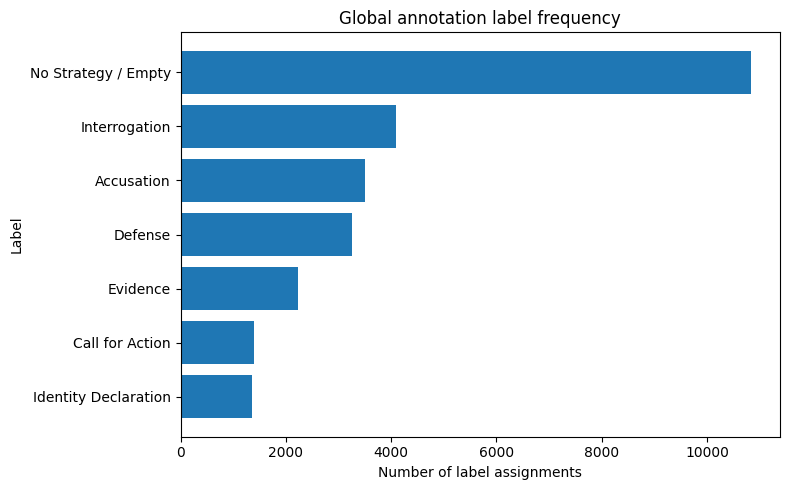

Saved plot to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots\global_label_counts_merged_no_strategy_empty.png


In [34]:
plot_df = label_counts_df.sort_values("n_label_assignments", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["label"], plot_df["n_label_assignments"])
plt.xlabel("Number of label assignments")
plt.ylabel("Label")
plt.title("Global annotation label frequency")
plt.tight_layout()

plot_path = PLOTS_DIR / "global_label_counts_merged_no_strategy_empty.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot to:", plot_path)

## Plot: strategy labels only

This excludes the merged non-strategy/empty label.

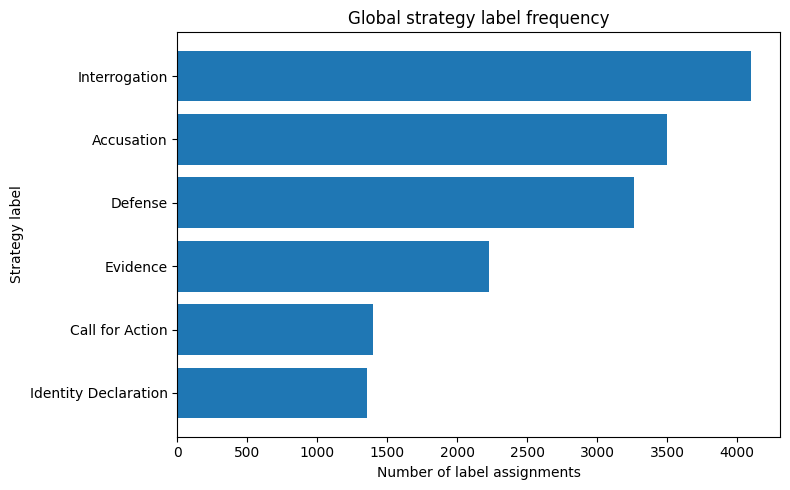

Saved plot to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots\global_strategy_label_counts.png


In [35]:
strategy_plot_df = (
    label_counts_df[
        label_counts_df["label"].isin(STRATEGY_LABELS)
    ]
    .sort_values("n_label_assignments", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(strategy_plot_df["label"], strategy_plot_df["n_label_assignments"])
plt.xlabel("Number of label assignments")
plt.ylabel("Strategy label")
plt.title("Global strategy label frequency")
plt.tight_layout()

plot_path = PLOTS_DIR / "global_strategy_label_counts.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot to:", plot_path)

## Table: strategy percentages by dialogue segment

This is a compact early/middle/late table. Values are percentages within each dialogue segment.

In [36]:
segment_strategy_plot_df = label_by_segment_df[
    label_by_segment_df["label"].isin(STRATEGY_LABELS)
].copy()

pivot_segment_df = segment_strategy_plot_df.pivot_table(
    index="label",
    columns="dialogue_segment",
    values="percent_within_segment",
    aggfunc="first",
)

display(pivot_segment_df)

pivot_segment_df.to_csv(TABLES_DIR / "strategy_percent_by_dialogue_segment_pivot.csv")

C:\Users\annab\AppData\Local\Temp\ipykernel_5976\2849634188.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_segment_df = segment_strategy_plot_df.pivot_table(


dialogue_segment,early,middle,late
label,,,
Accusation,9.221571,14.797907,15.166297
Call for Action,2.046683,3.796905,9.756098
Defense,10.865816,13.172253,12.616408
Evidence,8.129240,9.998887,6.917960
Identity Declaration,5.611130,5.244405,4.434590
Interrogation,15.879039,17.202984,13.037694


## Plot: label usage by final role

This plots label usage per final role as **labels per 100 utterances**. This normalization is important because different roles may have different numbers of turns.

In [43]:
def plot_label_usage_by_role(
    role_strategy_df: pd.DataFrame,
    role_col: str,
    output_prefix: str,
    title_role_name: str,
    min_role_turns: int = 20,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    role_label_rate_cols = [
        f"rate_{LABEL_TO_COL[label]}_per_turn"
        for label in sorted(ANALYSIS_LABELS)
    ]

    role_label_display_names = [
        label
        for label in sorted(ANALYSIS_LABELS)
    ]

    roles_to_exclude = {
        "Center Card",
        "Moderator",
        "NaN",
        "nan",
        "None",
        "",
    }

    role_plot_source_df = role_strategy_df.copy()
    role_plot_source_df[f"{role_col}_str"] = (
        role_plot_source_df[role_col]
        .astype("string")
        .fillna("NaN")
    )

    role_plot_source_df = role_plot_source_df[
        (role_plot_source_df["num_turns"] >= min_role_turns)
        & (~role_plot_source_df[f"{role_col}_str"].isin(roles_to_exclude))
    ].copy()

    role_order = (
        role_plot_source_df
        .sort_values("num_turns", ascending=True)[role_col]
        .tolist()
    )

    role_label_usage_df = (
        role_strategy_df
        .set_index(role_col)[role_label_rate_cols]
        .rename(columns=dict(zip(role_label_rate_cols, role_label_display_names)))
        * 100
    )

    role_label_usage_plot_df = role_label_usage_df.loc[role_order]

    support_cols = [
        role_col,
        "num_turns",
        "n_speakers",
        "n_games",
        "n_strategy_utterances",
        "n_no_strategy_empty",
    ]

    role_support_plot_df = (
        role_plot_source_df[support_cols]
        .sort_values("num_turns", ascending=False)
        .reset_index(drop=True)
    )

    display(role_support_plot_df)

    role_support_plot_df.to_csv(
        TABLES_DIR / f"{output_prefix}_support_summary_filtered.csv",
        index=False,
    )

    plt.figure(figsize=(11, max(5, 0.45 * len(role_label_usage_plot_df))))
    plt.imshow(role_label_usage_plot_df, aspect="auto")

    plt.xticks(
        ticks=np.arange(len(role_label_usage_plot_df.columns)),
        labels=role_label_usage_plot_df.columns,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        ticks=np.arange(len(role_label_usage_plot_df.index)),
        labels=role_label_usage_plot_df.index,
    )

    plt.colorbar(label="Label uses per 100 utterances")
    plt.xlabel("Annotation label")
    plt.ylabel(title_role_name)
    plt.title(f"Strategy label usage by {title_role_name.lower()}")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"{output_prefix}_label_usage_heatmap_filtered.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved plot to:", plot_path)

    display(role_label_usage_plot_df)

    role_label_usage_plot_df.to_csv(
        TABLES_DIR / f"{output_prefix}_label_usage_per_100_turns_filtered.csv"
    )

    role_label_deviation_df = (
        role_label_usage_plot_df
        - role_label_usage_plot_df.mean(axis=0)
    )

    max_abs_deviation = np.nanmax(np.abs(role_label_deviation_df.to_numpy()))

    plt.figure(figsize=(11, max(5, 0.45 * len(role_label_deviation_df))))
    plt.imshow(
        role_label_deviation_df,
        aspect="auto",
        vmin=-max_abs_deviation,
        vmax=max_abs_deviation,
    )

    plt.xticks(
        ticks=np.arange(len(role_label_deviation_df.columns)),
        labels=role_label_deviation_df.columns,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        ticks=np.arange(len(role_label_deviation_df.index)),
        labels=role_label_deviation_df.index,
    )

    plt.colorbar(label="Difference from average role, percentage points")
    plt.xlabel("Annotation label")
    plt.ylabel(title_role_name)
    plt.title(f"Strategy label usage by {title_role_name.lower()}: deviation from average")
    plt.tight_layout()

    plot_path = PLOTS_DIR / f"{output_prefix}_label_usage_deviation_heatmap_filtered.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved plot to:", plot_path)

    display(role_label_deviation_df)

    role_label_deviation_df.to_csv(
        TABLES_DIR / f"{output_prefix}_label_usage_deviation_from_average_filtered.csv"
    )

    return role_label_usage_plot_df, role_label_deviation_df

,speaker_end_role,num_turns,n_speakers,n_games,n_strategy_utterances,n_no_strategy_empty
0,Werewolf,6355,224,163,3508,2847
1,Troublemaker,3639,120,120,2022,1617
2,Robber,3438,118,118,1862,1576
3,Seer,2745,99,99,1560,1185
4,Tanner,2240,81,81,1319,921
5,Villager,1891,73,51,950,941
6,Insomniac,1250,49,49,668,582
7,Minion,587,27,27,331,256
8,Hunter,568,21,21,326,242
9,Drunk,355,12,12,173,182


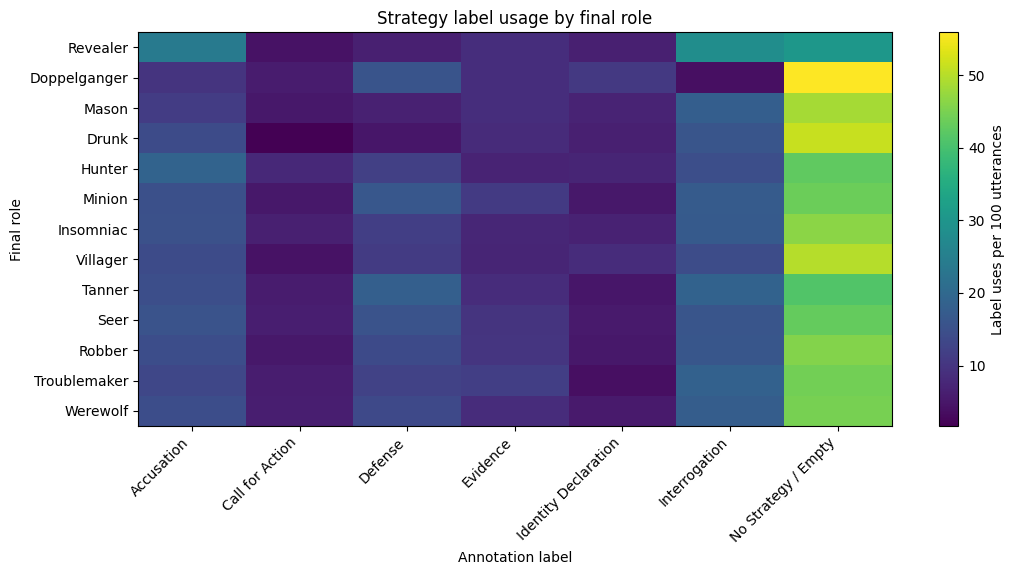

Saved plot to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots\final_role_label_usage_heatmap_filtered.png


,Accusation,Call for Action,Defense,Evidence,Identity Declaration,Interrogation,No Strategy / Empty
speaker_end_role,,,,,,,
Revealer,23.913043,4.347826,6.521739,8.695652,6.521739,28.260870,30.434783
Doppelganger,9.803922,5.882353,15.686275,8.823529,10.784314,3.921569,55.882353
Mason,11.377246,5.089820,6.586826,8.682635,7.185629,17.964072,48.502994
Drunk,14.084507,1.690141,5.070423,8.450704,6.478873,16.056338,51.267606
Hunter,18.838028,7.922535,11.971831,7.042254,7.218310,14.612676,42.605634
Minion,14.821124,5.281090,16.354344,10.902896,5.281090,17.206133,43.611584
Insomniac,15.200000,6.480000,11.680000,7.520000,6.880000,17.120000,46.560000
Villager,14.066631,4.283448,11.105235,7.297726,8.514014,14.383924,49.762031
Tanner,14.642857,5.758929,18.080357,8.482143,5.000000,18.660714,41.116071


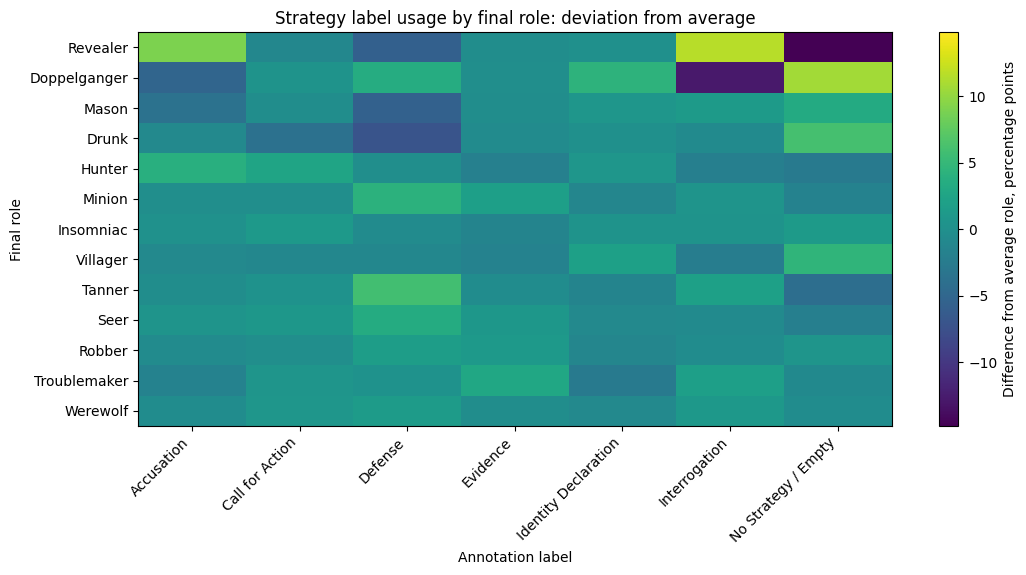

Saved plot to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots\final_role_label_usage_deviation_heatmap_filtered.png


,Accusation,Call for Action,Defense,Evidence,Identity Declaration,Interrogation,No Strategy / Empty
speaker_end_role,,,,,,,
Revealer,8.943178,-1.082392,-5.667956,-0.247905,0.046247,11.586763,-14.795042
Doppelganger,-5.165944,0.452134,3.496579,-0.120028,4.308822,-12.752538,10.652529
Mason,-3.592620,-0.340398,-5.602869,-0.260923,0.710137,1.289966,3.273170
Drunk,-0.885359,-3.740078,-7.119273,-0.492853,0.003382,-0.617768,6.037781
Hunter,3.868163,2.492317,-0.217864,-1.901304,0.742818,-2.061430,-2.624190
Minion,-0.148741,-0.149128,4.164649,1.959339,-1.194401,0.532027,-1.618240
Insomniac,0.230134,1.049781,-0.509695,-1.423557,0.404508,0.445894,1.330176
Villager,-0.903234,-1.146771,-1.084460,-1.645831,2.038522,-2.290182,4.532206
Tanner,-0.327009,0.328710,5.890662,-0.461415,-1.475492,1.986608,-4.113753


In [48]:
final_role_usage_df, final_role_deviation_df = plot_label_usage_by_role(
    role_strategy_df=final_role_strategy_df,
    role_col="speaker_end_role",
    output_prefix="final_role",
    title_role_name="Final role",
)

,speaker_start_role,num_turns,n_speakers,n_games,n_strategy_utterances,n_no_strategy_empty
0,Werewolf,6031,215,159,3284,2747
1,Troublemaker,3503,115,115,1976,1527
2,Robber,3177,115,115,1813,1364
3,Seer,2710,94,94,1510,1200
4,Tanner,2277,82,82,1353,924
5,Villager,1813,69,47,905,908
6,Insomniac,1232,48,48,618,614
7,Drunk,1160,41,41,595,565
8,Hunter,575,20,20,349,226
9,Minion,510,25,25,272,238


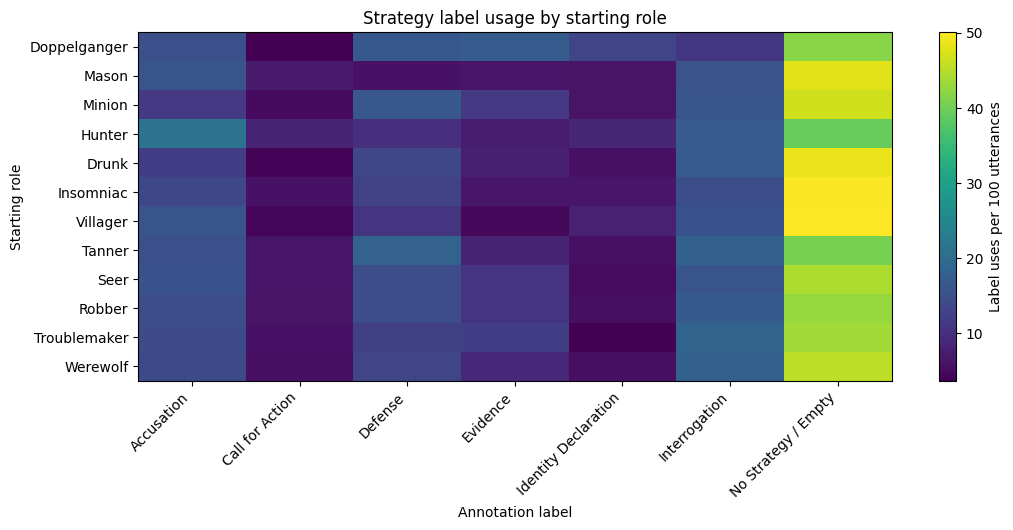

Saved plot to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots\start_role_label_usage_heatmap_filtered.png


,Accusation,Call for Action,Defense,Evidence,Identity Declaration,Interrogation,No Strategy / Empty
speaker_start_role,,,,,,,
Doppelganger,14.925373,3.731343,16.417910,17.164179,13.432836,11.194030,41.791045
Mason,15.778252,7.036247,5.970149,6.396588,6.183369,15.565032,47.974414
Minion,11.372549,5.098039,16.274510,11.372549,6.078431,15.882353,46.666667
Hunter,21.391304,8.173913,10.086957,7.304348,8.695652,17.043478,39.304348
Drunk,12.068966,4.051724,13.448276,7.758621,5.775862,17.068966,48.706897
Insomniac,13.717532,6.006494,12.824675,6.412338,6.493506,14.853896,49.837662
Villager,15.719801,4.467733,10.865968,4.633205,7.997794,15.388858,50.082736
Tanner,14.931928,6.368028,18.225736,8.300395,5.753184,18.006148,40.579710
Seer,15.313653,6.236162,14.575646,10.774908,5.276753,15.793358,44.280443


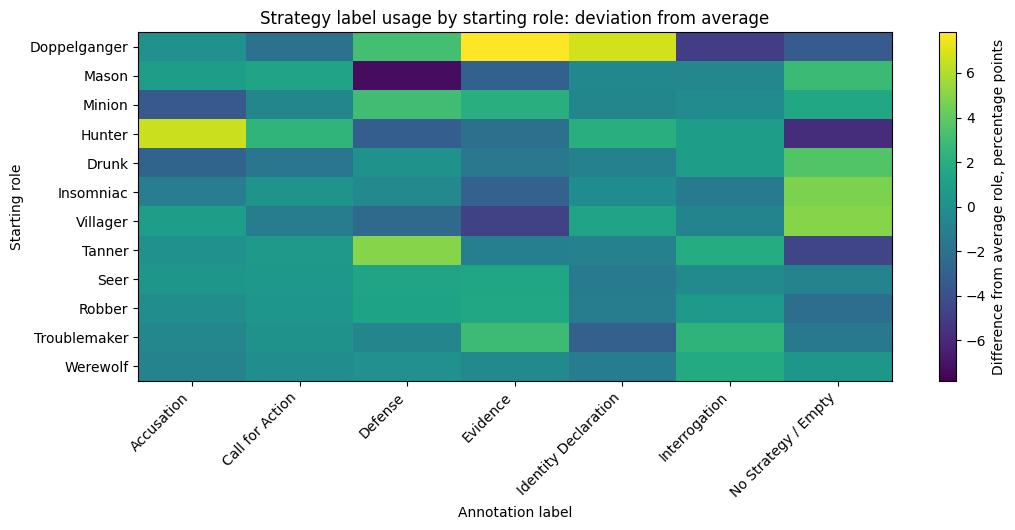

Saved plot to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots\start_role_label_usage_deviation_heatmap_filtered.png


,Accusation,Call for Action,Defense,Evidence,Identity Declaration,Interrogation,No Strategy / Empty
speaker_start_role,,,,,,,
Doppelganger,0.078868,-2.005747,3.157223,7.822495,6.739240,-4.968252,-3.317015
Mason,0.931747,1.299157,-7.290538,-2.945096,-0.510227,-0.597250,2.866354
Minion,-3.473956,-0.639051,3.013823,2.030865,-0.615165,-0.279929,1.558607
Hunter,6.544800,2.436823,-3.173731,-2.037337,2.002056,0.881196,-5.803712
Drunk,-2.777539,-1.685366,0.187589,-1.583064,-0.917734,0.906683,3.598837
Insomniac,-1.128972,0.269404,-0.436012,-2.929347,-0.200090,-1.308386,4.729603
Villager,0.873297,-1.269357,-2.394719,-4.708480,1.304198,-0.773424,4.974676
Tanner,0.085423,0.630938,4.965048,-1.041289,-0.940412,1.843866,-4.528349
Seer,0.467148,0.499072,1.314958,1.433223,-1.416843,-0.368924,-0.827617


In [49]:
start_role_usage_df, start_role_deviation_df = plot_label_usage_by_role(
    role_strategy_df=start_role_strategy_df,
    role_col="speaker_start_role",
    output_prefix="start_role",
    title_role_name="Starting role",
)

In [53]:
usage_df = start_role_usage_df.copy()

# Optionally ignore No Strategy / Empty when looking for strategic differences.
strategy_only_cols = [
    col for col in usage_df.columns
    if col != "No Strategy / Empty"
]

deviation_df = usage_df[strategy_only_cols] - usage_df[strategy_only_cols].mean(axis=0)

top_deviations_df = (
    deviation_df
    .stack()
    .reset_index()
)

top_deviations_df.columns = ["role", "label", "difference_from_average_pp"]
top_deviations_df["abs_difference_from_average_pp"] = (
    top_deviations_df["difference_from_average_pp"].abs()
)

top_deviations_df = top_deviations_df.sort_values(
    "abs_difference_from_average_pp",
    ascending=False,
)

display(top_deviations_df.head(40))

,role,label,difference_from_average_pp,abs_difference_from_average_pp
3,Doppelganger,Evidence,7.822495,7.822495
8,Mason,Defense,-7.290538,7.290538
4,Doppelganger,Identity Declaration,6.739240,6.739240
18,Hunter,Accusation,6.544800,6.544800
5,Doppelganger,Interrogation,-4.968252,4.968252
44,Tanner,Defense,4.965048,4.965048
39,Villager,Evidence,-4.708480,4.708480
12,Minion,Accusation,-3.473956,3.473956
20,Hunter,Defense,-3.173731,3.173731
2,Doppelganger,Defense,3.157223,3.157223


In [51]:
# ---------------------------------------------------------------------
# Support table for all starting roles.
# ---------------------------------------------------------------------

ROLE_COL = "speaker_start_role"

start_role_support_df = (
    speaker_strategy_df
    .groupby(ROLE_COL, dropna=False)
    .agg(
        n_games=("game_id", "nunique"),
        n_speakers=("speaker", "count"),
        n_utterances=("num_turns", "sum"),
        n_strategy_utterances=("n_strategy_utterances", "sum"),
        n_no_strategy_or_empty_utterances=("n_no_strategy_or_empty_utterances", "sum"),
    )
    .reset_index()
    .rename(columns={ROLE_COL: "role"})
)

start_role_support_df["strategy_utterance_rate"] = (
    start_role_support_df["n_strategy_utterances"]
    / start_role_support_df["n_utterances"]
)

start_role_support_df["no_strategy_or_empty_utterance_rate"] = (
    start_role_support_df["n_no_strategy_or_empty_utterances"]
    / start_role_support_df["n_utterances"]
)

start_role_support_df["strategy_utterance_percent"] = (
    start_role_support_df["strategy_utterance_rate"] * 100
)

start_role_support_df["no_strategy_or_empty_utterance_percent"] = (
    start_role_support_df["no_strategy_or_empty_utterance_rate"] * 100
)

start_role_support_df = start_role_support_df.sort_values(
    ["n_games", "n_utterances"],
    ascending=[False, False],
).reset_index(drop=True)

display(start_role_support_df)

start_role_support_df.to_csv(
    TABLES_DIR / "starting_role_support_summary_all_roles.csv",
    index=False,
)

,role,n_games,n_speakers,n_utterances,n_strategy_utterances,n_no_strategy_or_empty_utterances,strategy_utterance_rate,no_strategy_or_empty_utterance_rate,strategy_utterance_percent,no_strategy_or_empty_utterance_percent
0,Werewolf,159,215,6031,3284,2747,0.544520,0.455480,54.451998,45.548002
1,Troublemaker,115,115,3503,1976,1527,0.564088,0.435912,56.408792,43.591208
2,Robber,115,115,3177,1813,1364,0.570664,0.429336,57.066415,42.933585
3,Seer,94,94,2710,1510,1200,0.557196,0.442804,55.719557,44.280443
4,Tanner,82,82,2277,1353,924,0.594203,0.405797,59.420290,40.579710
5,Insomniac,48,48,1232,618,614,0.501623,0.498377,50.162338,49.837662
6,Villager,47,69,1813,905,908,0.499173,0.500827,49.917264,50.082736
7,Drunk,41,41,1160,595,565,0.512931,0.487069,51.293103,48.706897
8,NaN,33,42,395,213,182,0.539241,0.460759,53.924051,46.075949
9,Minion,25,25,510,272,238,0.533333,0.466667,53.333333,46.666667


In [52]:
# ---------------------------------------------------------------------
# Merge normalized usage with support, so every row is interpretable.
# ---------------------------------------------------------------------

start_role_usage_with_support_df = (
    start_role_usage_df
    .reset_index()
    .rename(columns={"speaker_start_role": "role"})
    .merge(
        start_role_support_df[
            ["role", "n_games", "n_speakers", "n_utterances"]
        ],
        on="role",
        how="left",
    )
)

# Put support columns first.
support_cols = ["role", "n_games", "n_speakers", "n_utterances"]
label_cols = [
    col for col in start_role_usage_with_support_df.columns
    if col not in support_cols
]

start_role_usage_with_support_df = start_role_usage_with_support_df[
    support_cols + label_cols
]

display(start_role_usage_with_support_df)

start_role_usage_with_support_df.to_csv(
    TABLES_DIR / "starting_role_label_usage_with_support.csv",
    index=False,
)

,role,n_games,n_speakers,n_utterances,Accusation,Call for Action,Defense,Evidence,Identity Declaration,Interrogation,No Strategy / Empty
0,Doppelganger,6,6,134,14.925373,3.731343,16.417910,17.164179,13.432836,11.194030,41.791045
1,Mason,10,12,469,15.778252,7.036247,5.970149,6.396588,6.183369,15.565032,47.974414
2,Minion,25,25,510,11.372549,5.098039,16.274510,11.372549,6.078431,15.882353,46.666667
3,Hunter,20,20,575,21.391304,8.173913,10.086957,7.304348,8.695652,17.043478,39.304348
4,Drunk,41,41,1160,12.068966,4.051724,13.448276,7.758621,5.775862,17.068966,48.706897
5,Insomniac,48,48,1232,13.717532,6.006494,12.824675,6.412338,6.493506,14.853896,49.837662
6,Villager,47,69,1813,15.719801,4.467733,10.865968,4.633205,7.997794,15.388858,50.082736
7,Tanner,82,82,2277,14.931928,6.368028,18.225736,8.300395,5.753184,18.006148,40.579710
8,Seer,94,94,2710,15.313653,6.236162,14.575646,10.774908,5.276753,15.793358,44.280443
9,Robber,115,115,3177,14.699402,6.137866,14.542021,10.827825,5.476865,16.745357,42.933585


## Final quick summary

This prints the main numbers to inspect before moving to model-vote analysis.

In [42]:
print("Dataset strategy annotation summary")
print("-" * 80)

print(f"Games: {utterance_df['game_id'].nunique()}")
print(f"Utterances: {len(utterance_df)}")
print(f"Speakers/game pairs: {len(speaker_strategy_df)}")
print()

print(
    f"Strategy utterances: "
    f"{utterance_df['has_strategy'].sum()} "
    f"({utterance_df['has_strategy'].mean():.2%})"
)

print(
    f"No-strategy-or-empty utterances: "
    f"{utterance_df['has_no_strategy_or_empty'].sum()} "
    f"({utterance_df['has_no_strategy_or_empty'].mean():.2%})"
)

print(
    f"Raw empty-annotation utterances: "
    f"{utterance_df['has_raw_empty_annotation'].sum()} "
    f"({utterance_df['has_raw_empty_annotation'].mean():.2%})"
)

print(
    f"Raw No Strategy utterances: "
    f"{utterance_df['has_raw_no_strategy'].sum()} "
    f"({utterance_df['has_raw_no_strategy'].mean():.2%})"
)

print(
    f"Multi-label utterances: "
    f"{utterance_df['has_multiple_annotations'].sum()} "
    f"({utterance_df['has_multiple_annotations'].mean():.2%})"
)

print()
print("Most frequent merged labels:")
display(label_counts_df.head(10))

print()
print("Most frequent label co-occurrences:")
display(cooccurrence_df.head(10))

print()
print("Main outputs saved under:")
print(TABLES_DIR)
print(PLOTS_DIR)

Dataset strategy annotation summary
--------------------------------------------------------------------------------
Games: 191
Utterances: 24070
Speakers/game pairs: 887

Strategy utterances: 13226 (54.95%)
No-strategy-or-empty utterances: 10844 (45.05%)
Raw empty-annotation utterances: 51 (0.21%)
Raw No Strategy utterances: 10793 (44.84%)
Multi-label utterances: 2391 (9.93%)

Most frequent merged labels:


,label,n_label_assignments,n_utterances,n_games,percent_of_label_assignments,percent_of_utterances,percent_of_games
6,No Strategy / Empty,10844,10844,191,40.617275,45.051932,100.000000
5,Interrogation,4102,4102,190,15.364447,17.041961,99.476440
0,Accusation,3499,3499,190,13.105851,14.536768,99.476440
2,Defense,3266,3266,187,12.233126,13.568758,97.905759
3,Evidence,2229,2229,189,8.348940,9.260490,98.952880
1,Call for Action,1399,1399,180,5.240093,5.812214,94.240838
4,Identity Declaration,1359,1359,189,5.090269,5.646032,98.952880



Most frequent label co-occurrences:


,label_a,label_b,n_cooccurrences
0,Defense,Evidence,588
2,Accusation,Defense,334
4,Evidence,Identity Declaration,329
3,Defense,Identity Declaration,270
8,Accusation,Interrogation,215
10,Accusation,Evidence,203
5,Defense,Interrogation,201
6,Accusation,Identity Declaration,173
1,Call for Action,Defense,155
11,Call for Action,Interrogation,117



Main outputs saved under:
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\tables
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\persuasion\dataset_distribution\plots
